In [89]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_distances
import matplotlib.pyplot as plt

df= pd.read_csv("../data/BMW/sentiment_preprocessed_reviews.csv")
print(df.shape)
print(df.head())

(10498, 14)
                               reviewId   
0  fb7fb9f2-75ad-4660-8c9d-ad05bae0739d  \
1  86b51f94-88da-42b0-87ac-fcbe94e86ea8   
2  20f31dc9-de57-46c7-b503-2fdc2ca757c4   
3  dffdfe4f-70a8-40f2-b684-ba6a5858fe55   
4  4c00e344-ebb7-486d-b0ed-8ef2b0fa0cbb   

                                             content  score  thumbsUpCount   
0  every time i tap on the widget to open the app...      3              0  \
1  i have a vehicle with comfort access and a sam...      2              0   
2                        can't add my e34 and e39 :/      1              0   
3  bmw stands for its reliability n performance i...      5              0   
4  the lack of support for octopus intelligent go...      2              0   

  reviewCreatedVersion                   at appVersion company   
0               5.11.4  2026-03-07 16:35:07     5.11.4     BMW  \
1               5.11.4  2026-03-07 14:42:54     5.11.4     BMW   
2               5.11.4  2026-03-07 09:50:37     5.11.4     BMW

In [50]:
df["sentiment"].value_counts()

sentiment
positive    5515
negative    4041
neutral      942
Name: count, dtype: int64

In [51]:
# Wir filtern zunächst die negativen Reviews heraus, um die Daten für die Issue Detection vorzubereiten
negative_reviews = df[df["sentiment"] == "negative"]
print("Number of negative reviews:", negative_reviews.shape[0])

Number of negative reviews: 4041


In [52]:
# Wir schauen uns die ersten Zeilen der negativen Reviews an, um einen Eindruck von den Daten zu bekommen
negative_reviews[["content", "lemmatized_text"]].head()

,content,lemmatized_text
1,i have a vehicle with comfort access and a sam...,vehicle comfort access samsung galaxy s26 ultr...
2,can't add my e34 and e39 :/,can not add e34 e39
4,the lack of support for octopus intelligent go...,lack support octopus intelligent go frustratin...
5,to have my bmw charge overnight in a 'time slo...,bmw charge overnight time slot preprogram depa...
6,loss of push notifications issue is now fixed ...,loss push notification issue fix thank since j...


In [53]:
#Für Embeddings nehmen wir den bereinigten Text, 
#da dieser bereits von Stoppwörtern und Sonderzeichen bereinigt wurde.
#Da wir jedoch einen Sentence Transformer verwenden, werden wir die cleaned_text Spalte verwenden, 
#da diese bereits in einem Format vorliegt, das für die Erstellung von Embeddings geeignet ist.
#Lemmatization wurde gemacht, um die Performance der Sentiment Modelle zu verbessern, 
#da sie die Anzahl der einzigartigen Wörter reduziert und somit die Generalisierung des Modells verbessert. 
#Für die Issue Detection hingegen ist es wichtig, 
#den Kontext und die spezifischen Formulierungen der Kunden zu erhalten, 
#um die Probleme besser zu identifizieren. 
# Daher verwenden wir hier den bereinigten Text, um die Embeddings zu erstellen.
texts= negative_reviews["clean_text"].astype(str).tolist()
print(len(texts))

4041


In [54]:
#Wir prüfen die ersten 5 Einträge der Texte, um sicherzustellen, 
#dass sie korrekt bereinigt wurden und für die Erstellung von Embeddings geeignet sind.
texts[:5]

['vehicle comfort access samsung galaxy s26 ultra uwb yet cannot set phone digital key bmw support confirmed everything supported car country problem simply app wouldnt properly support car 2020 ridiculous premium paid vehicle connected drive services',
 'cant add e34 e39',
 'lack support octopus intelligent go frustrating cant understand removed popular ev tariff uk',
 'bmw charge overnight time slot preprogram departure time necessary set departure time allow charge overnight makes sense software designed franz kafka',
 'loss push notifications issue fixed thank since january update unable schedule service items nominated dealers services repairs available currently unable retrieve available services repair']

In [55]:
#Sentence Transformer Embeddings erstellen
#Jeder Review wird in einen semantischen Vektor umgewandelt, der die Bedeutung des Textes einfängt.
from sentence_transformers import SentenceTransformer
#Modell laden (paraphrase-multilingual-MiniLM-L12-v2 ist ein kompaktes Modell, 
#das gut für die Erstellung von Embeddings geeignet ist). 
#Wir haben sowohl deutsche als auch englische Reviews, daher ist ein multilingual Modell sinnvoll.
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
#Embeddings erstellen
embeddings = model.encode(texts, show_progress_bar=True)
print(embeddings.shape)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6248.06it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 127/127 [00:09<00:00, 13.45it/s]

(4041, 384)


In [56]:
from sklearn.metrics import silhouette_score

inertia=[]
silhouette_scores= []
k_values= range(2, 15)
for k in k_values:
    kmeans= KMeans(n_clusters=k, random_state=42)
    cluster_labels= kmeans.fit_predict(embeddings)
    inertia.append(kmeans.inertia_)
    silhouette_avg= silhouette_score(embeddings, cluster_labels)
    silhouette_scores.append(silhouette_avg)

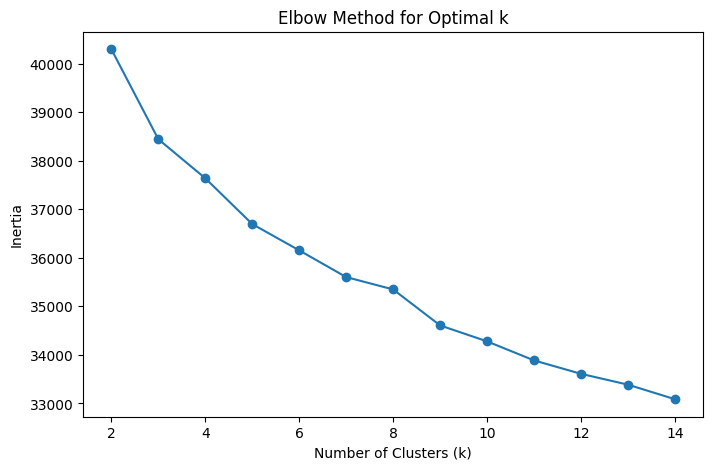

In [57]:
#Hier machen wir den Elbow Plot, um die optimale Anzahl an Clustern zu bestimmen.
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

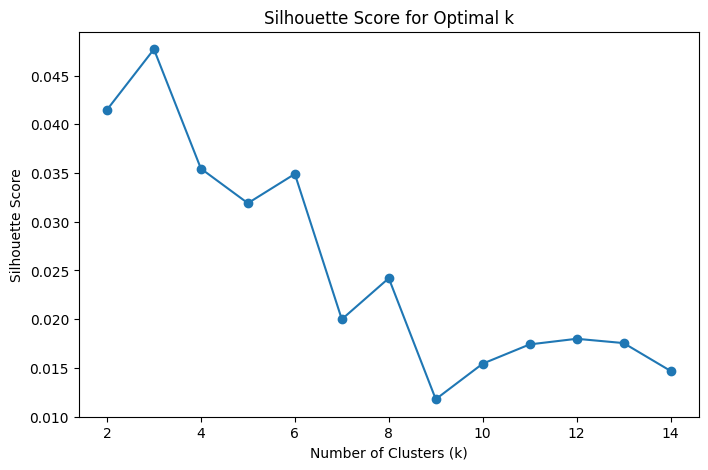

In [58]:
#Nun machen wir den Silhouette Score Plot, um die optimale Anzahl an Clustern zu bestimmen.
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Optimal k")
plt.show()

##### Die optimale Anzahl an Clustern wurde mithilfe der Elbow-Methode und des Silhouette-Scores bestimmt. Der Elbow-Plot zeigt einen deutlichen Knick bei k=5, ab dem die Inertia nr noch geringfügig weiter abnimmt. Obwohl der Silhouette-Score bei k=2 seinen höchsten Wert erreicht, würde diese Clusteranzahl zu sehr breiten und wenig differenzierten Clustern führen.Daher wurde k=5 als ausgewogene Lösung gewählt, da diese Anzahl gut interpretierbare Issue-Kategorien ermöglicht und gleichzeitig eine angemessene Clustertrennung beibehält.

In [59]:
#Clustering der Issues. 
# Hier verwenden wir K-Means, um die negativen Reviews in verschiedene Gruppen zu unterteilen,
#die jeweils ein bestimmtes Problem oder Thema repräsentieren.
from sklearn.cluster import KMeans
#Anzahl der Cluster festlegen (z.B. 5)
k=5
kmeans = KMeans(n_clusters=k, random_state=42)
#Clustering durchführen
cluster= kmeans.fit_predict(embeddings)
#Cluster-Zuordnungen der Reviews erhalten
negative_reviews["cluster"]= cluster
print(negative_reviews[["content", "cluster"]].head())

                                             content  cluster
1  i have a vehicle with comfort access and a sam...        2
2                        can't add my e34 and e39 :/        2
4  the lack of support for octopus intelligent go...        3
5  to have my bmw charge overnight in a 'time slo...        2
6  loss of push notifications issue is now fixed ...        0


/var/folders/19/zb4149m55_7gpwbwlsr01jdh0000gn/T/ipykernel_56068/2381599473.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_reviews["cluster"]= cluster


In [60]:
#Threshold für die Erkennung neuer Probleme festlegen
distances_list =[]
for emb in embeddings:
    distances= cosine_distances([emb], kmeans.cluster_centers_)
    min_distance=distances.min()
    distances_list.append(min_distance)
distances_list= np.array(distances_list)

print("Average distance:", distances_list.mean())
print("Max distance:", distances_list.max())
DISTANCE_THRESHOLD= np.percentile(distances_list, 90)
print("Selected threshold:", DISTANCE_THRESHOLD)

Average distance: 0.38697428
Max distance: 0.8281676
Selected threshold: 0.5542823076248169


In [61]:
DISTANCE_THRESHOLD=0.55
print("Final threshold used:", DISTANCE_THRESHOLD)

Final threshold used: 0.55


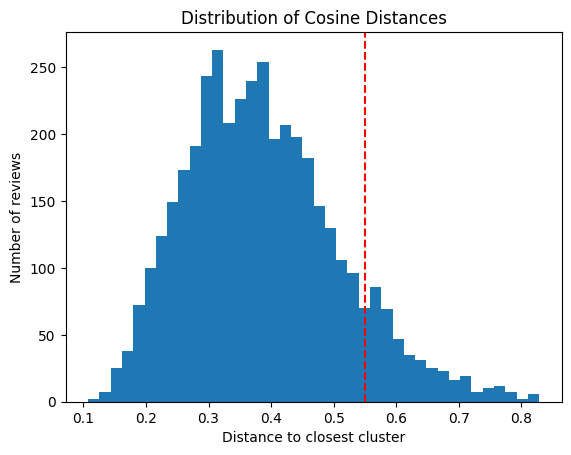

In [62]:
plt.hist(distances_list, bins=40)
plt.axvline(DISTANCE_THRESHOLD, color="red", linestyle="--")
plt.title("Distribution of Cosine Distances")
plt.xlabel("Distance to closest cluster")
plt.ylabel("Number of reviews")
plt.show()

##### UMAP-Visualisierung erstellen

In [63]:
print(type(embeddings))
print(embeddings.shape)
print(np.isnan(embeddings).sum())
print(np.isinf(embeddings).sum())

<class 'numpy.ndarray'>
(4041, 384)
0
0


In [64]:
import umap
import numpy as np

embeddings=np.array(embeddings).astype(np.float32)
umap_model=umap.UMAP(n_neighbors=15, n_components=2, metric="cosine", random_state=42)
embedding_2d= umap_model.fit_transform(embeddings)
print(embedding_2d.shape)

/Users/ayhan/Desktop/DS_Bootcamp/Capstone_Martin_Ayhan/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(4041, 2)


In [65]:
negative_reviews["x"]= embedding_2d[:, 0]
negative_reviews["y"]= embedding_2d[:, 1]

/var/folders/19/zb4149m55_7gpwbwlsr01jdh0000gn/T/ipykernel_56068/2197036124.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_reviews["x"]= embedding_2d[:, 0]
/var/folders/19/zb4149m55_7gpwbwlsr01jdh0000gn/T/ipykernel_56068/2197036124.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_reviews["y"]= embedding_2d[:, 1]


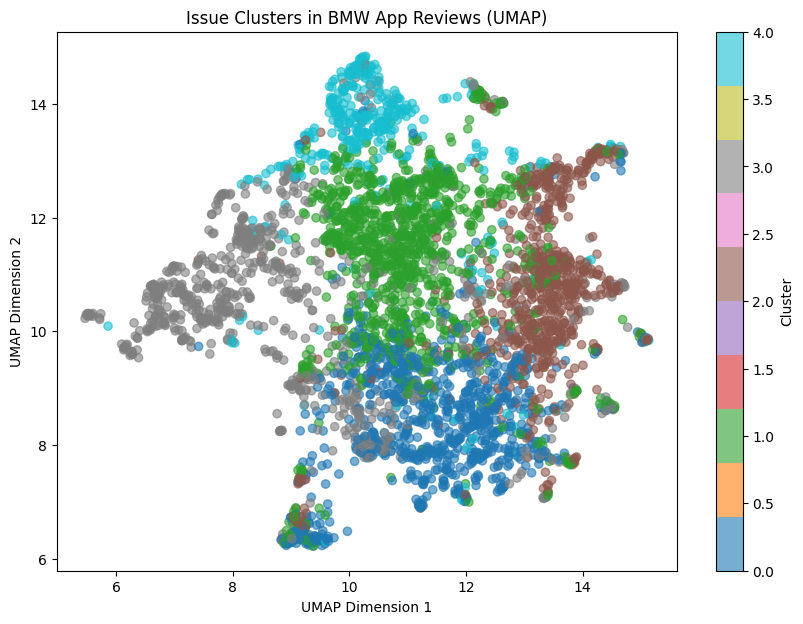

In [90]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))
scatter = plt.scatter(negative_reviews["x"], negative_reviews["y"], c=negative_reviews["cluster"], cmap="tab10", alpha=0.6)
plt.title("Issue Clusters in BMW App Reviews (UMAP)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

In [67]:
#Wir schauen uns die Anzahl der Reviews in jedem Cluster an, um zu sehen, 
#wie die negativen Reviews gruppiert wurden.
negative_reviews.groupby("cluster").size()

cluster
0     895
1    1150
2     787
3     817
4     392
dtype: int64

In [68]:
for i in range(k):
    print("\nCluster", i)
    sample= negative_reviews[negative_reviews["cluster"] == i]["content"].head(5)
    for review in sample:
        print("-", review)  


Cluster 0
- loss of push notifications issue is now fixed - thank you. since the january update i am unable to schedule service items from nominated or other dealers - "no services or repairs available. we are currently unable to retrieve available services or repair"
- very bad experience, like these guys are from the neaderthal compared to the current times. app goes în a loop when adding a new vehicle and bringing me to the same menu, without completing the add. really really bad! also a lot of other poorly developed functionalities. long delay to activate car functions, sometimes no response. bad.
- useless, will not add my vehicle from its vin number. bugs out then closes. uninstalled then came here to warn people how useless it is, unless you want to buy a car, then it works lol
- was a battery hog before. this is now ok. synching with the car is however still very slow. bmw please pay attention, smart charging with frank energy is unreliable since you have blocked access to the

In [69]:
#Code für wichtigste Wörter in jedem Cluster
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
#TF-IDF Vektorisierung der negativen Reviews
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(negative_reviews["clean_text"])
terms= vectorizer.get_feature_names_out()
#Wichtigste Wörter pro Cluster identifizieren
for i in range(k):
    print("\nCluster", i)
    #Reviews im aktuellen Cluster auswählen
    cluster_indices = negative_reviews["cluster"] == i
    cluster_tfidf = X[cluster_indices.values]
    #Durchschnittliche TF-IDF Werte pro Wort im Cluster berechnen
    mean_tfidf = np.asarray(cluster_tfidf.mean(axis=0)).ravel()
    #Top 10 Wörter mit höchsten durchschnittlichen TF-IDF Werten auswählen
    top_words = mean_tfidf.argsort()[-10:][::-1]
    
    print([terms[j] for j in top_words])



Cluster 0
['car', 'app', 'vehicle', 'fahrzeug', 'update', 'auto', 'doesnt', 'charging', 'status', 'cant']

Cluster 1
['app', 'mehr', 'funktioniert', 'update', 'seit', 'neu', 'immer', 'leider', 'mal', 'anmelden']

Cluster 2
['bmw', 'app', 'connected', 'samsung', 'funktioniert', 'android', 'mehr', 'update', 'phone', 'digital']

Cluster 3
['mehr', 'funktioniert', 'update', 'seit', 'immer', 'leider', 'anmelden', 'möglich', 'geht', 'neu']

Cluster 4
['login', 'log', 'password', 'app', 'cant', 'error', 'every', 'time', 'keeps', 'use']


In [70]:
#Wir benennen jetzt die Cluster 
cluster_labels= {
    0: "Vehicle Connectivity Issues",
    1: "Login / Authentication Problems",
    2: "Feature / Software Support Issues",
    3: "App Functionality Problems",
    4: "Charging / Remote Services Issues"
}
negative_reviews["issues"]= negative_reviews["cluster"].map(cluster_labels)
print(negative_reviews[["content", "issues"]].head())

                                             content   
1  i have a vehicle with comfort access and a sam...  \
2                        can't add my e34 and e39 :/   
4  the lack of support for octopus intelligent go...   
5  to have my bmw charge overnight in a 'time slo...   
6  loss of push notifications issue is now fixed ...   

                              issues  
1  Feature / Software Support Issues  
2  Feature / Software Support Issues  
4         App Functionality Problems  
5  Feature / Software Support Issues  
6        Vehicle Connectivity Issues  


/var/folders/19/zb4149m55_7gpwbwlsr01jdh0000gn/T/ipykernel_56068/855991787.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_reviews["issues"]= negative_reviews["cluster"].map(cluster_labels)


In [71]:
#Wir zeigen nun welche Issues am häufigsten in den negativen Reviews genannt werden
issue_counts= negative_reviews["issues"].value_counts()
print(issue_counts)

issues
Login / Authentication Problems      1150
Vehicle Connectivity Issues           895
App Functionality Problems            817
Feature / Software Support Issues     787
Charging / Remote Services Issues     392
Name: count, dtype: int64


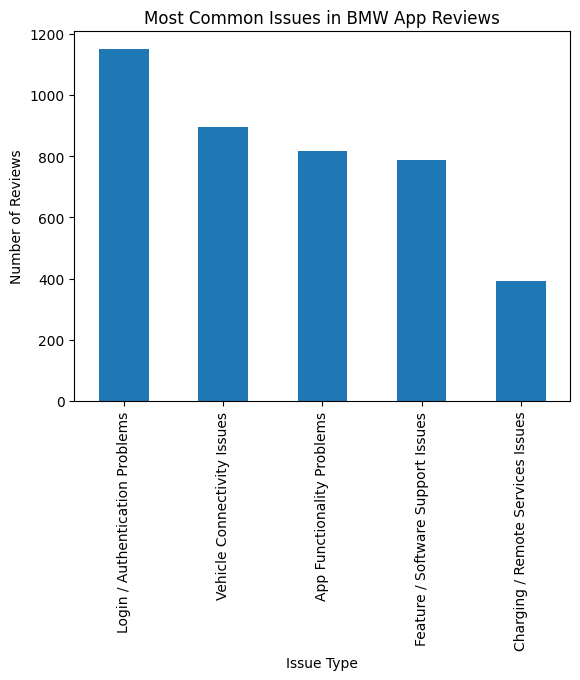

In [84]:
import matplotlib.pyplot as plt
issue_counts.plot(kind="bar")
plt.title("Most Common Issues in BMW App Reviews")
plt.xlabel("Issue Type")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=90)
plt.show()

In [73]:
#Clusterzentren speichern. Diese brauchen wir für New Issue Detection, 
#um neue Reviews den bestehenden Clustern zuzuordnen.
cluster_centers=kmeans.cluster_centers_
print(cluster_centers.shape)

(5, 384)


In [74]:
#Hier erstellen wir eine Funktion, die neue Reviews den bestehenden Clustern zuordnet,
#indem sie die Ähnlichkeit der neuen Review-Embeddings zu den Clusterzentren berechnet.
def detect_issue(review_text):
    #Embedding für die neue Review erstellen
    embedding = model.encode([review_text])
    #Ähnlichkeit zu den Clusterzentren berechnen
    distances = cosine_distances(embedding, kmeans.cluster_centers_)
    closest_cluster=distances.argmin()
    min_distance = distances.min()
    print("Min distance:", min_distance)
    if min_distance> DISTANCE_THRESHOLD: #Schwellenwert für die Zuordnung zu einem bestehenden Cluster (wurde rechnerisch ermittelt)
        return "New Issue Detected", None
    else:
        return "Known Issue", closest_cluster
    
    

In [75]:
#Wenn ein neues Issue erkannt wird, erzeugen wir automatisch KEywords als Label.
def generate_issue_label(text):
    vector= vectorizer.transform([text])
    tfidf_scores=np.asarray(vector.todense()).flatten()
    top_indices= tfidf_scores.argsort()[-3:][::-1]
    words= [terms[i] for i in top_indices]
    return ", ".join(words)

In [76]:
#Jetzt verbinden wir beide Funktionen 
def analyze_review(review_text):
    status, cluster_id = detect_issue(review_text)
    print("Detected cluster:", cluster_id)
    if status == "New Issue Detected":
        label = generate_issue_label(review_text)
        return {"status": "New Issue Detected", "Suggested_label": label}
    else:
        label= cluster_labels.get(int(cluster_id), "Other Issue")
        return {"status": "Known Issue", "issue_label": label}

In [77]:
test_review= "The BMW app crashes every time I try to open vehicle status"
print(analyze_review(test_review))

Min distance: 0.33612335
Detected cluster: 0
{'status': 'Known Issue', 'issue_label': 'Vehicle Connectivity Issues'}


In [78]:
test_review= "Voice assistant in the BMW app is broken"
print(analyze_review(test_review))

Min distance: 0.6129966
Detected cluster: None
{'status': 'New Issue Detected', 'Suggested_label': 'broken, bmw, app'}


In [79]:
test_review= "Die BMW App stürzt jedes Mal ab, wenn ich versuche, den Fahrzeugstatus zu öffnen."
print(analyze_review(test_review))

Min distance: 0.35175133
Detected cluster: 0
{'status': 'Known Issue', 'issue_label': 'Vehicle Connectivity Issues'}


In [81]:
#Wir erstellen hiermit einen "models" Ordner
import os
os.makedirs("models", exist_ok=True)

In [82]:
#Nun speichern wir die Modelle
import joblib
joblib.dump(kmeans, "models/kmeans_model.pkl")
#Threshold speichern
joblib.dump(DISTANCE_THRESHOLD, "models/distance_threshold.pkl")
#Cluster Labels speichern
joblib.dump(cluster_labels, "models/cluster_labels.pkl")
print("Models saved successfully")

Models saved successfully
